# Personality Prediction: Introvert vs Extrovert
Bahasuru Nayanakantha
p.h.d.bahasuru@gmail.com

In [160]:
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/bahasurunayanakantha/personality-dataset/personality_dataset.csv


## Load dataset

In [161]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/bahasurunayanakantha/personality-dataset/personality_dataset.csv')

print(f'Shape: {df.shape}')  
df.head(10)

# Data types and basic info
df.info()

Shape: (2900, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


## Exploratory Data Analysis (EDA)

### Check first 10 values of dataset

In [162]:
df.head(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
5,1.0,No,7.0,5.0,No,6.0,6.0,Extrovert
6,4.0,No,9.0,NaN,No,7.0,7.0,Extrovert
7,2.0,No,8.0,4.0,No,7.0,8.0,Extrovert
8,10.0,Yes,1.0,3.0,Yes,0.0,3.0,Introvert
9,0.0,No,8.0,6.0,No,13.0,8.0,Extrovert


### Check missing values

In [163]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing values per column:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing values per column:
                           Missing Count  Missing %
Time_spent_Alone                      63       2.17
Stage_fear                            73       2.52
Social_event_attendance               62       2.14
Going_outside                         66       2.28
Drained_after_socializing             52       1.79
Friends_circle_size                   77       2.66
Post_frequency                        65       2.24


## Target Distribution

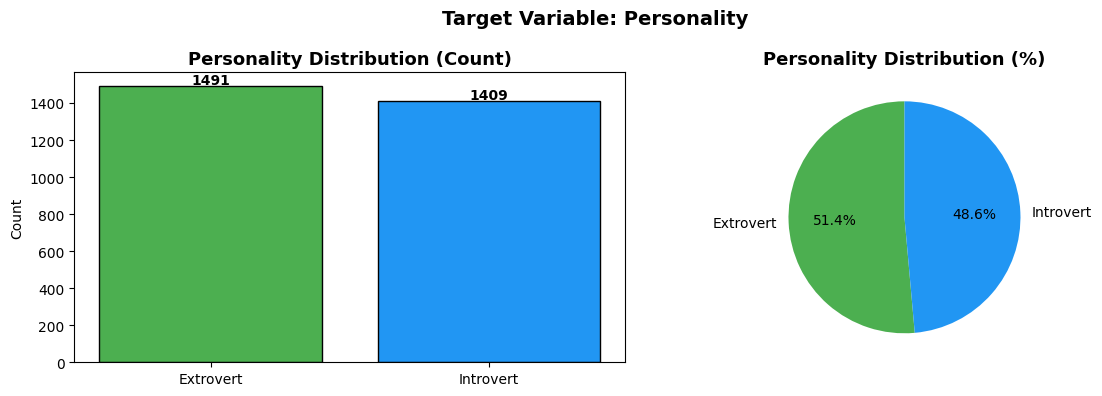

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Personality'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#2196F3'], edgecolor='black')
axes[0].set_title('Personality Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3'], startangle=90)
axes[1].set_title('Personality Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Personality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [165]:
counts = df['Personality'].value_counts()

imbalance_ratio = counts.max() / counts.min()

print("Imbalance Ratio:", round(imbalance_ratio, 2))

Imbalance Ratio: 1.06


The imbalance ratio is 1.06, indicating that the dataset is well balanced with nearly equal numbers of introverts and extroverts. no need for oversampling techniques.

### Numerical feature distributions

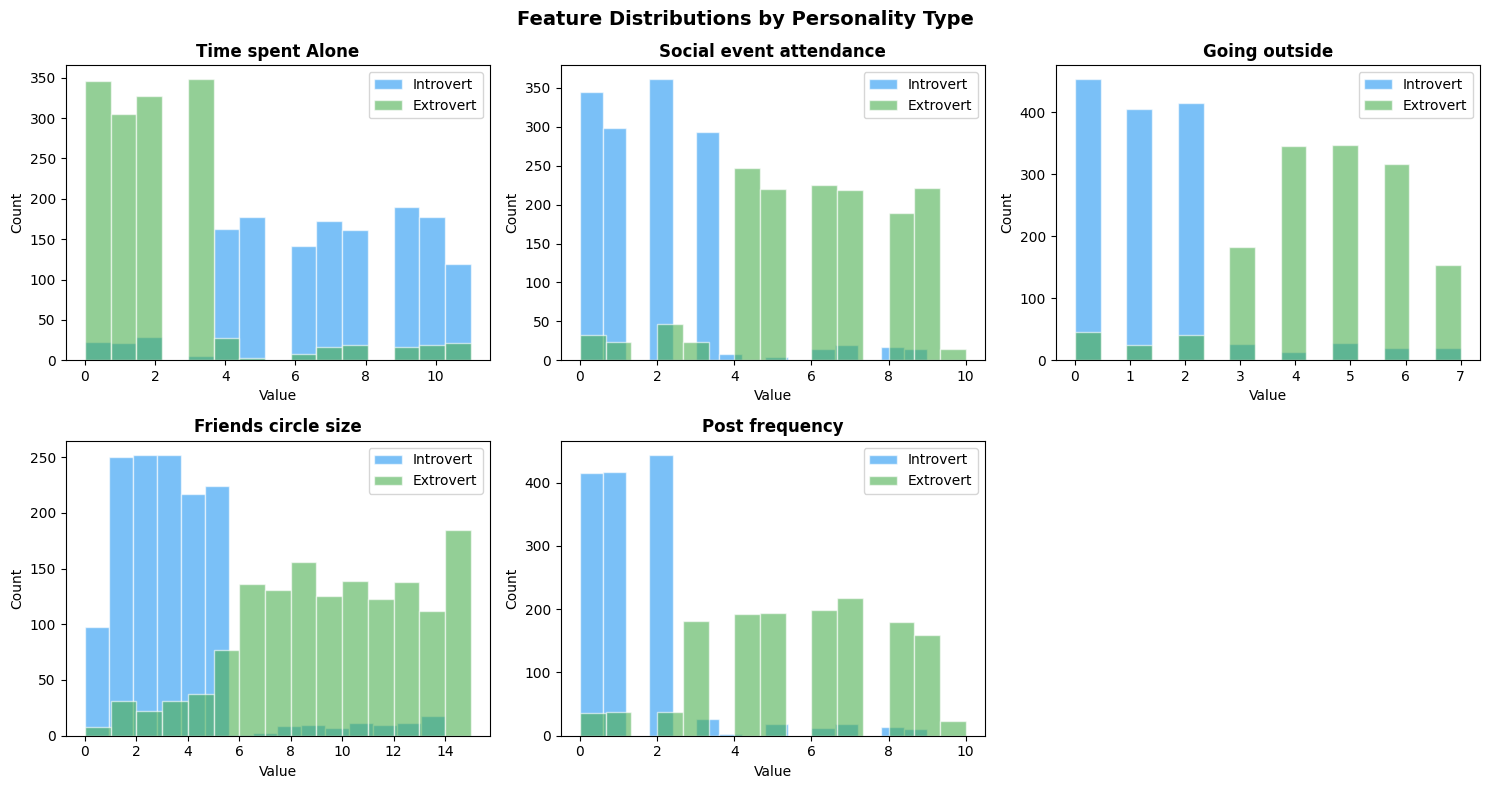

In [166]:
numerical_cols = ['Time_spent_Alone', 'Social_event_attendance',
                  'Going_outside', 'Friends_circle_size', 'Post_frequency']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for personality, color in [('Introvert', '#2196F3'), ('Extrovert', '#4CAF50')]:
        subset = df[df['Personality'] == personality][col].dropna()
        axes[i].hist(subset, bins=15, alpha=0.6, label=personality, color=color, edgecolor='white')
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Personality Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Categorical features vs. Personality

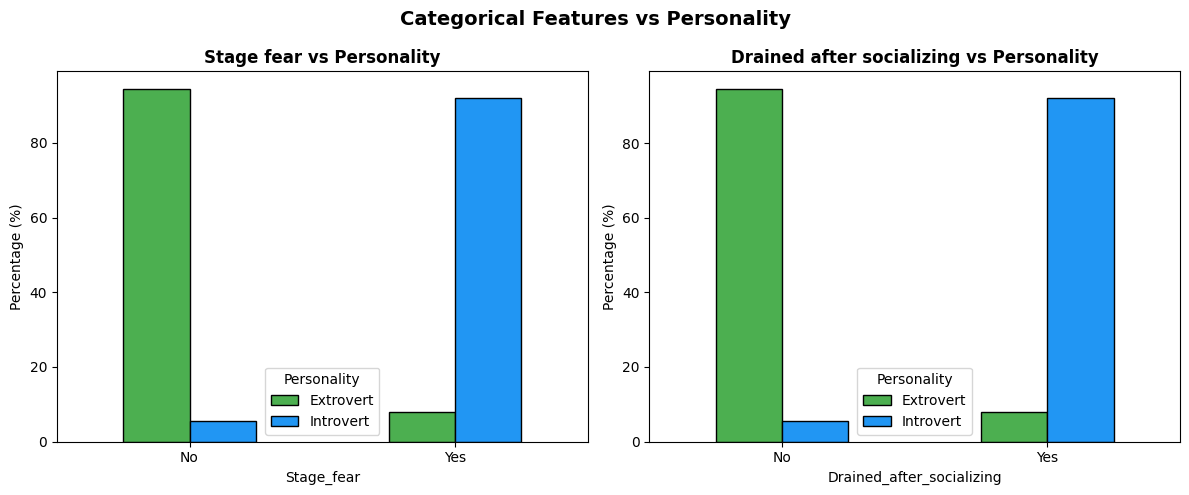

In [167]:
categorical_cols = ['Stage_fear', 'Drained_after_socializing']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#2196F3'], edgecolor='black', rot=0)
    axes[i].set_title(f'{col.replace("_", " ")} vs Personality', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Personality')

plt.suptitle('Categorical Features vs Personality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation heatmap

In [168]:
# convert categorical features to numbers get full picture
df_temp = df.copy()
df_temp['Stage_fear'] = df_temp['Stage_fear'].map({'Yes': 1, 'No': 0})
df_temp['Drained_after_socializing'] = df_temp['Drained_after_socializing'].map({'Yes': 1, 'No': 0})
df_temp['Personality'] = df_temp['Personality'].map({'Introvert': 1, 'Extrovert': 0})

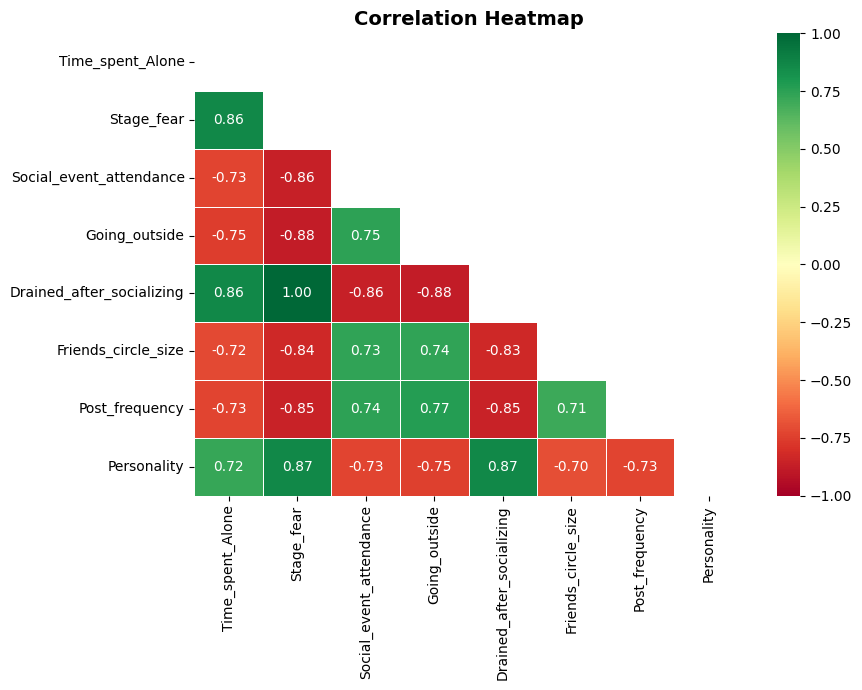

In [169]:
plt.figure(figsize=(9, 7))
corr = df_temp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

all variables have high correlation with the target variable.

## Data Preprocessing

### Encode categoricals values

In [170]:
print(df['Stage_fear'].unique())
print(df['Drained_after_socializing'].unique())
print(df['Personality'].unique())

['No' 'Yes' nan]
['No' 'Yes' nan]
['Extrovert' 'Introvert']


In [171]:
# Yes = 1, No = 0  (keeps interpretability simple)
df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})

# Encode target: Introvert=1, Extrovert=0
df['Personality'] = df['Personality'].map({'Introvert': 1, 'Extrovert': 0})

print('Encoding complete.')
df.head(10)

Encoding complete.


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,0
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,1
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,1
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,0
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,0
5,1.0,0.0,7.0,5.0,0.0,6.0,6.0,0
6,4.0,0.0,9.0,NaN,0.0,7.0,7.0,0
7,2.0,0.0,8.0,4.0,0.0,7.0,8.0,0
8,10.0,1.0,1.0,3.0,1.0,0.0,3.0,1
9,0.0,0.0,8.0,6.0,0.0,13.0,8.0,0


### Separate features (X) and target (y)

In [172]:
X = df.drop('Personality', axis=1)  # 7 feature columns
y = df['Personality']               # target column

print('Feature columns:', X.columns.tolist())
print('Target value counts:')
print(y.value_counts())

Feature columns: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']
Target value counts:
Personality
0    1491
1    1409
Name: count, dtype: int64


### Train-Test Split (80/20)

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

Training set:   2320 samples
Test set:       580 samples

Train class distribution:
Personality
0    1193
1    1127
Name: count, dtype: int64

Test class distribution:
Personality
0    298
1    282
Name: count, dtype: int64


## Build ML Pipelines
### Why use a Pipeline?
A `Pipeline` chains preprocessing + model into one object.
- When fill null values, prevents data leakage (imputer/scaler fits only on training data)
- Makes deployment clean - one object handles everything
- Test 5 different algorithms to find the best one

NOTE - For this problem, deep learning is not necessary because the dataset is relatively small and consists of structured tabular data. Traditional machine learning models like Logistic Regression, Random Forest, and Gradient Boosting are more suitable as they handle missing values, capture non-linear relationships, and perform well on limited data. These models also provide better interpretability compared to neural networks, making them a more practical choice for this task.

In [174]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
 

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # fill NaNs with column median
        ('scaler', StandardScaler()),                   # normalize to mean=0, std=1
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),

    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # max_depth=5 prevents overfitting
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # 200 trees, ensemble reduces variance
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
    ]),

    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # boosting: each tree corrects previous errors
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ))
    ])
    
}

print('5 model pipelines defined')

5 model pipelines defined


## Train & Evaluate All Models
### Evaluation Strategy:
- 10-Fold Stratified Cross-Validation on training data - reliable performance estimate
- Test set accuracy - final unbiased evaluation
- compare all 5 models side by side

In [175]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,  classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<22} {"CV Accuracy":<18} {"Test Accuracy"}')
print('-' * 55)

for name, model in models.items():
    # 5-fold CV on training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    # Train on full training set, evaluate on test set
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'model': model
    }
    print(f'{name:<22} {cv_scores.mean():.6f} ± {cv_scores.std():.6f}   {test_acc:.6f}')

Model                  CV Accuracy        Test Accuracy
-------------------------------------------------------
Logistic Regression    0.929310 ± 0.014832   0.905172
Decision Tree          0.938793 ± 0.016783   0.917241
Random Forest          0.938362 ± 0.016588   0.915517
Gradient Boosting      0.932328 ± 0.016018   0.912069
XGBoost                0.937069 ± 0.015684   0.915517


To evaluate overfitting and underfitting, I compare cross-validation accuracy with test accuracy. In this case, all models show very small differences between CV and test performance (around 1–2%), which indicates good generalization. Since there is no large drop in test accuracy, there is no strong sign of overfitting or underfitting, and all models are performing reliably on unseen data.

### Visual comparison of all models

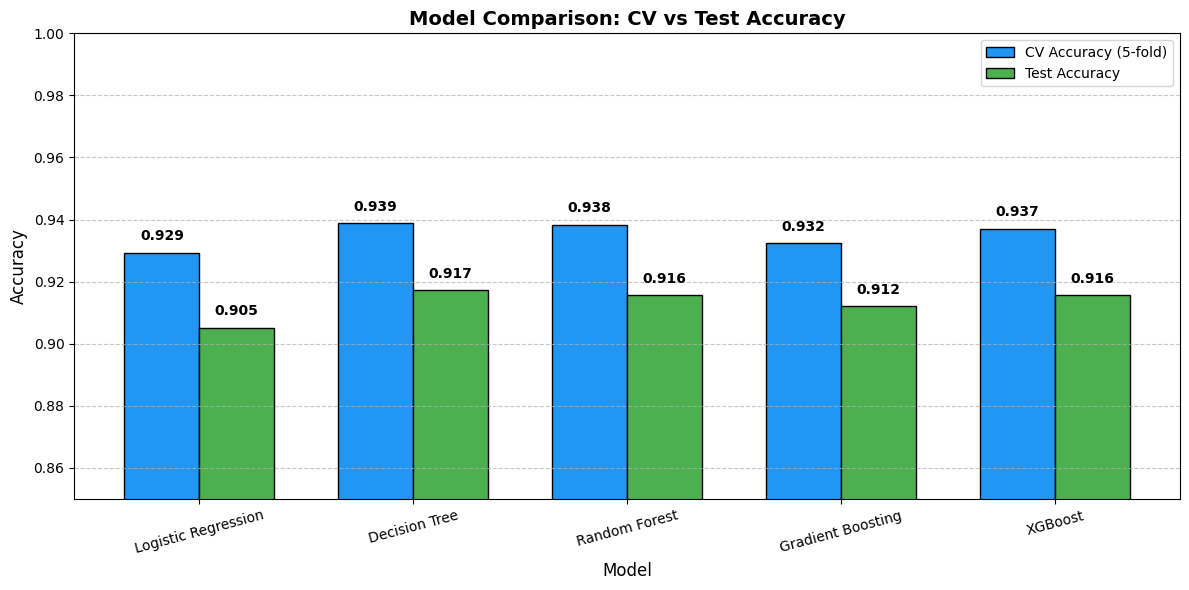

In [176]:
model_names = list(results.keys())
cv_means = [results[m]['cv_mean'] for m in model_names]
test_accs = [results[m]['test_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, cv_means, width, label='CV Accuracy (5-fold)', color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='#4CAF50', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: CV vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Improve model further

### Hyperparameter Tuning 

The models above use reasonable default parameters, but  can do better with systematic search.

Why tune?
- Default parameters are generic - they are not optimised for dataset.
- `GridSearchCV` tests every combination of parameters using cross-validation and picks the best.
- This avoids manual trial-and-error guessing.

I tuned the top 2 models (Random Forest + Decision Tree) since these performed best in initial comparison.

#### Tune Random Forest

In [177]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'clf__n_estimators':    [100, 200, 300],     # number of trees
    'clf__max_depth':       [5, 10, 15, None],   # depth of each tree (None = unlimited)
    'clf__min_samples_split': [2, 5, 10],        # min samples to split a node
    'clf__min_samples_leaf':  [1, 2, 4]          # min samples in a leaf node
}

rf_tuner = GridSearchCV(
    models['Random Forest'],
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print('Tuning Random Forest... ')
rf_tuner.fit(X_train, y_train)

rf_tuned_test_acc = accuracy_score(y_test, rf_tuner.predict(X_test))

print('\n Random Forest Tuning Results:')
print(f'   Best Parameters : {rf_tuner.best_params_}')
print(f'   Best CV Accuracy: {rf_tuner.best_score_:.6f}')
print(f'   Test Accuracy   : {rf_tuned_test_acc:.6f}')
print(f'   Improvement     : +{(rf_tuned_test_acc - results["Random Forest"]["test_acc"]):.6f}')

Tuning Random Forest... 

 Random Forest Tuning Results:
   Best Parameters : {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
   Best CV Accuracy: 0.938793
   Test Accuracy   : 0.917241
   Improvement     : +0.001724


#### Tune Decision Tree

In [178]:
dt_param_grid = {
    'clf__max_depth':        [3, 5, 7, 10, None],   # how deep the tree can grow
    'clf__min_samples_split': [2, 5, 10, 20],       # min samples needed to split a node
    'clf__min_samples_leaf':  [1, 2, 4, 8],         # min samples required at a leaf
    'clf__criterion':        ['gini', 'entropy']    # split quality measure
}

dt_tuner = GridSearchCV(
    models['Decision Tree'],
    dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print('Tuning Decision Tree...')
dt_tuner.fit(X_train, y_train)

dt_tuned_test_acc = accuracy_score(y_test, dt_tuner.predict(X_test))

print('\n Decision Tree Tuning Results:')
print(f'   Best Parameters : {dt_tuner.best_params_}')
print(f'   Best CV Accuracy: {dt_tuner.best_score_:.6f}')
print(f'   Test Accuracy   : {dt_tuned_test_acc:.6f}')
print(f'   Improvement     : +{(dt_tuned_test_acc - results["Decision Tree"]["test_acc"]):.6f}')

Tuning Decision Tree...

 Decision Tree Tuning Results:
   Best Parameters : {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
   Best CV Accuracy: 0.938793
   Test Accuracy   : 0.917241
   Improvement     : +0.000000


## Select Overall Best Model (Including Tuned)
pick the model with highest test accuracy

In [179]:
# Add tuned models to results dict
results['Random Forest (Tuned)'] = {
    'cv_mean':  rf_tuner.best_score_,
    'cv_std':   0.0,  
    'test_acc': rf_tuned_test_acc,
    'model':    rf_tuner.best_estimator_
}
results['Decision Tree (Tuned)'] = {
    'cv_mean':  dt_tuner.best_score_,
    'cv_std':   0.0,
    'test_acc': dt_tuned_test_acc,
    'model':    dt_tuner.best_estimator_
}

# Pick overall winner
best_name  = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']

print(f' Best Model: {best_name}')
print(f' Test Accuracy: {results[best_name]["test_acc"]*100:.2f}%')

 Best Model: Decision Tree
 Test Accuracy: 91.72%


##  Detailed Analysis of Best Model
 

### Classification Report

In [180]:
y_pred = best_model.predict(X_test)
print('Classification Report:')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Extrovert', 'Introvert']))

Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



### Confusion Matrix

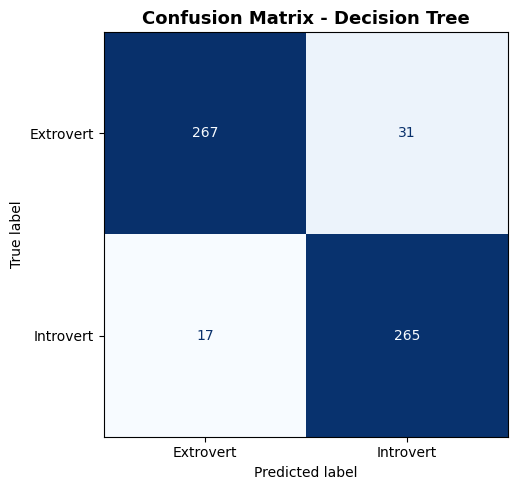

In [181]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Extrovert', 'Introvert'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Learning Curves

Plotting learning curve for: Decision Tree



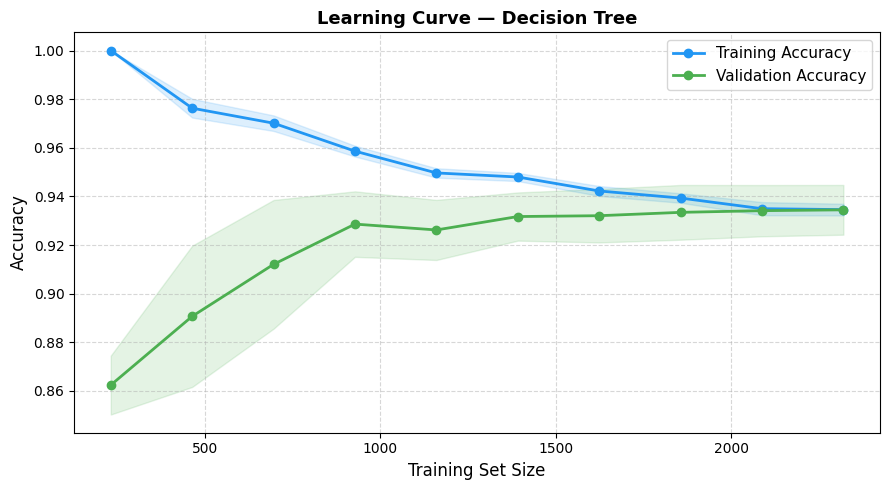

Final Training Accuracy  : 0.9346
Final Validation Accuracy: 0.9345
Gap (train - val)        : 0.0001
Well-fitted — no significant overfitting.


In [182]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title='Learning Curve', cv_folds=5):
   
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),   # 10 points from 10% to 100% of training data
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#2196F3', lw=2, label='Training Accuracy')
    plt.fill_between(train_sizes,
                     train_mean - train_std,
                     train_mean + train_std, alpha=0.15, color='#2196F3')

    plt.plot(train_sizes, val_mean, 'o-', color='#4CAF50', lw=2, label='Validation Accuracy')
    plt.fill_between(train_sizes,
                     val_mean - val_std,
                     val_mean + val_std, alpha=0.15, color='#4CAF50')

    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Auto-diagnose
    final_gap = train_mean[-1] - val_mean[-1]
    print(f'Final Training Accuracy  : {train_mean[-1]:.4f}')
    print(f'Final Validation Accuracy: {val_mean[-1]:.4f}')
    print(f'Gap (train - val)        : {final_gap:.4f}')
    if final_gap < 0.02:
        print('Well-fitted — no significant overfitting.')
    elif final_gap < 0.05:
        print('Slight overfitting — consider stronger regularisation.')
    else:
        print('Overfitting — model memorises training data.')


print(f'Plotting learning curve for: {best_name}\n')
plot_learning_curve(best_model, X, y, title=f'Learning Curve — {best_name}')

### ROC Curve & AUC Score

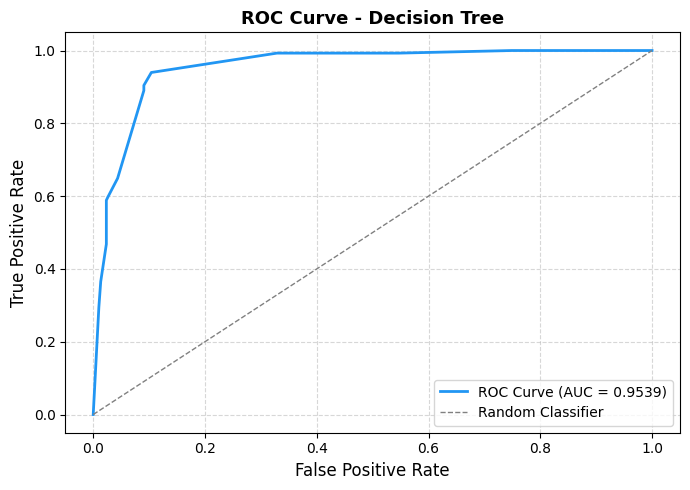

AUC Score: 0.9539  


In [183]:
y_prob = best_model.predict_proba(X_test)[:, 1]  # probability of being Introvert
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_name}', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'AUC Score: {auc:.4f}  ')

An AUC score of 0.9539 indicates excellent model performance, showing that the model is highly effective at distinguishing between the two classes with strong overall classification ability.

### Precision-Recall Curve

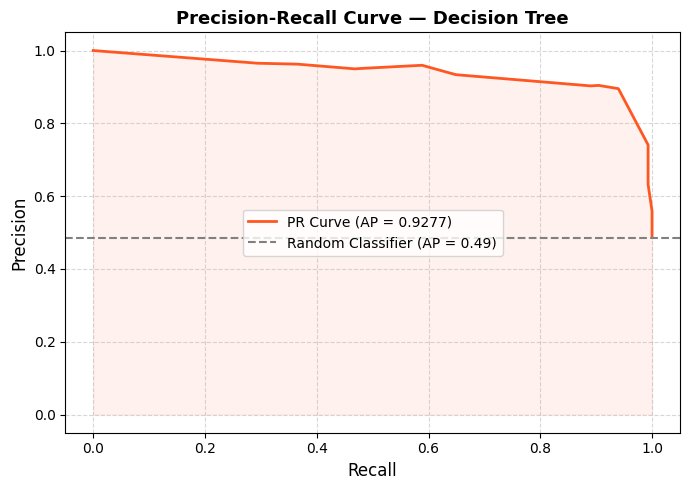

Average Precision (AP): 0.9277


In [184]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

# Baseline = fraction of positive class in test set
baseline = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='#FF5722', lw=2,
         label=f'PR Curve (AP = {ap:.4f})')
plt.axhline(y=baseline, color='gray', linestyle='--',
            label=f'Random Classifier (AP = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='#FF5722')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f'Precision-Recall Curve — {best_name}', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {ap:.4f}')


An Average Precision (AP) score of 0.9277 indicates that the model achieved excellent performance in distinguishing between the personality classes.

### Feature Importances

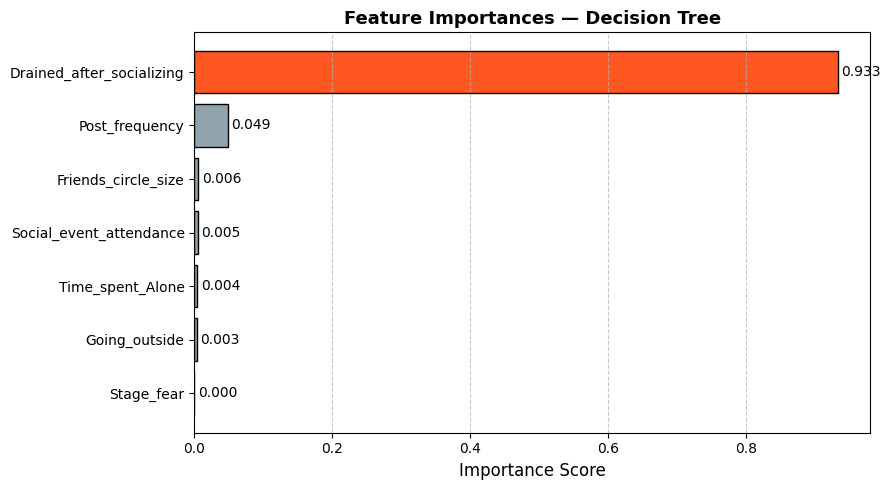

In [185]:
clf = best_model.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)

    colors = ['#FF5722' if v > 0.1 else '#90A4AE' for v in fi.values]
    
    plt.figure(figsize=(9, 5))
    bars = plt.barh(fi.index, fi.values, color=colors, edgecolor='black')
    for bar in bars:
        plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.3f}', va='center', fontsize=10)
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
else:
    print('This model does not expose feature_importances_')

Drained_after_socializing is the single strongest predictor of personality type

## Final Summary

In [186]:
summary_rows = []
for name, info in results.items():
    summary_rows.append({
        'Model': name,
        'CV Accuracy': f"{info['cv_mean']:.4f}",
        'Test Accuracy': f"{info['test_acc']:.4f}",
        'Test Accuracy %': f"{info['test_acc']*100:.2f}%"
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values('Test Accuracy', ascending=False)
    .reset_index(drop=True)
)
summary_df.index += 1  # rank starts at 1

print('=' * 65)
print('              FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(summary_df.to_string())

print(f'\nBest Model     : {best_name}')
print(f'Test Accuracy  : {results[best_name]["test_acc"]*100:.2f}%')
print(f'AUC-ROC Score  : {auc:.4f}')
print(f'Avg Precision  : {ap:.4f}')

              FINAL MODEL COMPARISON SUMMARY
                   Model CV Accuracy Test Accuracy Test Accuracy %
1          Decision Tree      0.9388        0.9172          91.72%
2  Random Forest (Tuned)      0.9388        0.9172          91.72%
3  Decision Tree (Tuned)      0.9388        0.9172          91.72%
4          Random Forest      0.9384        0.9155          91.55%
5                XGBoost      0.9371        0.9155          91.55%
6      Gradient Boosting      0.9323        0.9121          91.21%
7    Logistic Regression      0.9293        0.9052          90.52%

Best Model     : Decision Tree
Test Accuracy  : 91.72%
AUC-ROC Score  : 0.9539
Avg Precision  : 0.9277


## Save model

In [187]:
import joblib

MODEL_PATH = '/kaggle/working/personality_model.pkl'
joblib.dump(best_model, MODEL_PATH)
print(f'Model saved  -- {MODEL_PATH}')


loaded_model = joblib.load(MODEL_PATH)
test_sample = pd.DataFrame([{
    'Time_spent_Alone': 8.0,
    'Stage_fear': 1,
    'Social_event_attendance': 2.0,
    'Going_outside': 2.0,
    'Drained_after_socializing': 1,
    'Friends_circle_size': 3.0,
    'Post_frequency': 2.0
}])

prediction = loaded_model.predict(test_sample)[0]
confidence = max(loaded_model.predict_proba(test_sample)[0]) * 100
label = 'Introvert' if prediction == 1 else 'Extrovert'

print(f'\nSample prediction: {label} ({confidence:.1f}% confidence)')
print('Model loaded and working correctly!')

Model saved  -- /kaggle/working/personality_model.pkl

Sample prediction: Introvert (87.0% confidence)
Model loaded and working correctly!
